# 📊 Amazon India Products — Data Visualization
**CodeAlpha Data Analytics Internship | Task 3**

| | |
|---|---|
| **Dataset** | Amazon India Product Reviews (1,465 products) |
| **Task** | Task 3 — Data Visualization |
| **Tools** | Python · Matplotlib · Seaborn |
---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
print("✅ Libraries loaded")


✅ Libraries loaded


## 1. Load & Prepare Data

In [2]:
df_raw = pd.read_csv('../amazon.csv')

df = df_raw.copy()

def clean_price(col):
    return col.str.replace('₹', '', regex=False).str.replace(',', '', regex=False).str.strip().astype(float)

df['discounted_price'] = clean_price(df['discounted_price'])
df['actual_price']     = clean_price(df['actual_price'])
df['discount_pct']     = df['discount_percentage'].str.replace('%', '', regex=False).str.strip().astype(float)
df['rating']           = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count']     = df['rating_count'].str.replace(',', '', regex=False).str.strip()
df['rating_count']     = pd.to_numeric(df['rating_count'], errors='coerce')
df['main_category']    = df['category'].str.split('|').str[0]
df['sub_category']     = df['category'].str.split('|').str[1].fillna('Unknown')
df['savings']          = df['actual_price'] - df['discounted_price']
df['discount_bucket']  = pd.cut(df['discount_pct'],
    bins=[0,20,40,60,80,100], labels=['0-20%','21-40%','41-60%','61-80%','81-100%'])

df_clean = df.dropna(subset=['rating']).copy()
cat_counts = df_clean['main_category'].value_counts()
print(f"✅ Data ready: {df_clean.shape[0]} products")


✅ Data ready: 1464 products


## Visualization 1 — Product Distribution by Category

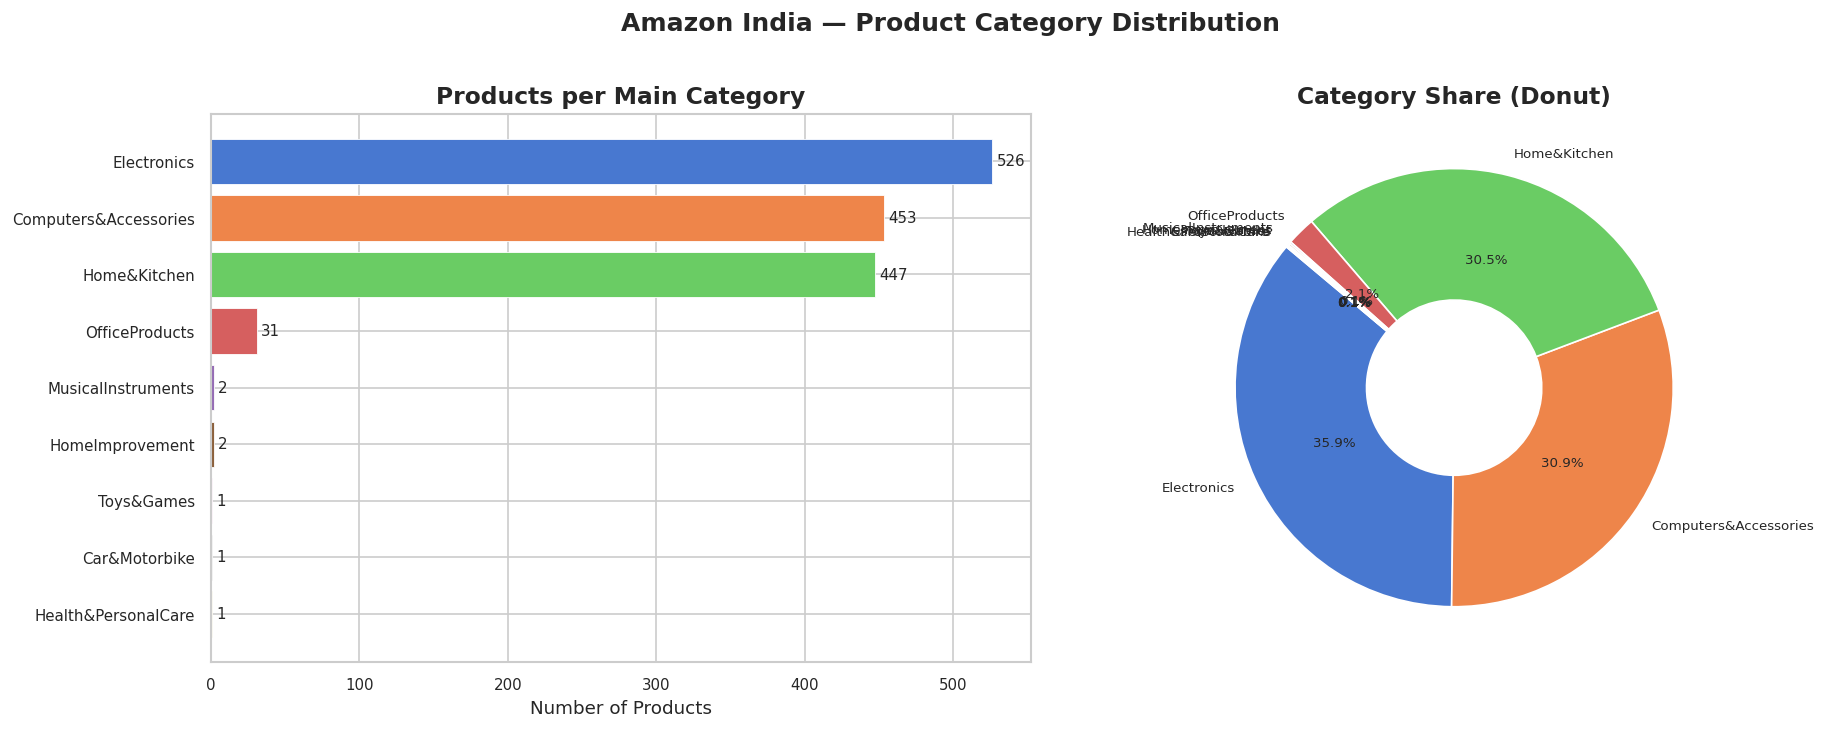

✅ Saved


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = sns.color_palette('muted', n_colors=len(cat_counts))
axes[0].barh(cat_counts.index, cat_counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Products per Main Category')
axes[0].set_xlabel('Number of Products')
for i, v in enumerate(cat_counts.values):
    axes[0].text(v + 3, i, str(v), va='center', fontsize=9)
axes[0].invert_yaxis()

wedge_props = dict(width=0.6)
axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
            colors=colors, wedgeprops=wedge_props, startangle=140,
            textprops={'fontsize': 8})
axes[1].set_title('Category Share (Donut)')

plt.suptitle('Amazon India — Product Category Distribution', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz1_category_distribution.png', bbox_inches='tight')
plt.show()
print("✅ Saved")


## Visualization 2 — Rating Distribution

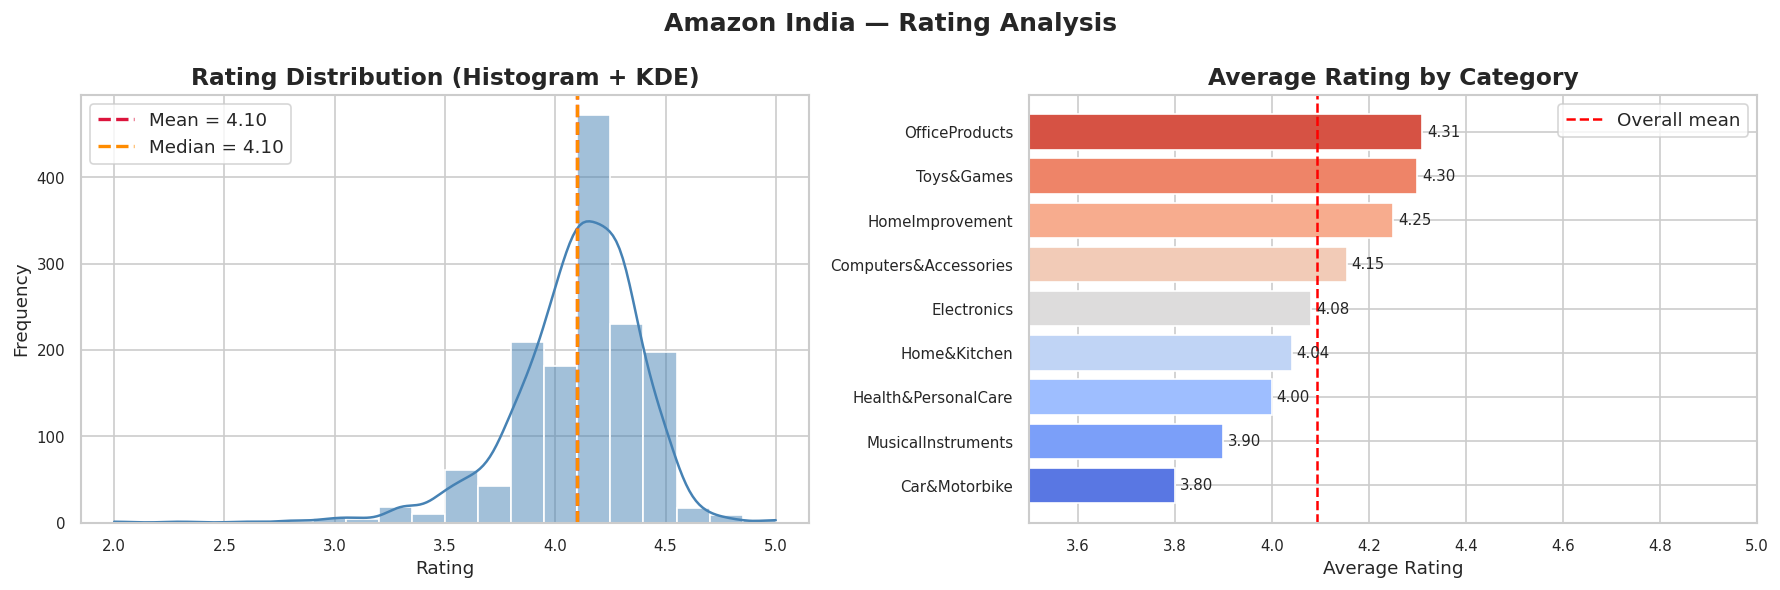

✅ Saved


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_clean['rating'], bins=20, kde=True, color='steelblue', edgecolor='white', ax=axes[0])
axes[0].axvline(df_clean['rating'].mean(), color='crimson', linestyle='--', linewidth=2,
                label=f"Mean = {df_clean['rating'].mean():.2f}")
axes[0].axvline(df_clean['rating'].median(), color='darkorange', linestyle='--', linewidth=2,
                label=f"Median = {df_clean['rating'].median():.2f}")
axes[0].set_title('Rating Distribution (Histogram + KDE)')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frequency')
axes[0].legend()

cat_rating = df_clean.groupby('main_category')['rating'].mean().sort_values()
axes[1].barh(cat_rating.index, cat_rating.values,
             color=sns.color_palette('coolwarm', n_colors=len(cat_rating)))
axes[1].axvline(cat_rating.mean(), color='red', linestyle='--', linewidth=1.5, label='Overall mean')
axes[1].set_title('Average Rating by Category')
axes[1].set_xlabel('Average Rating')
axes[1].set_xlim(3.5, 5.0)
for i, v in enumerate(cat_rating.values):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)
axes[1].legend()

plt.suptitle('Amazon India — Rating Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz2_rating_analysis.png', bbox_inches='tight')
plt.show()
print("✅ Saved")


## Visualization 3 — Discount Analysis

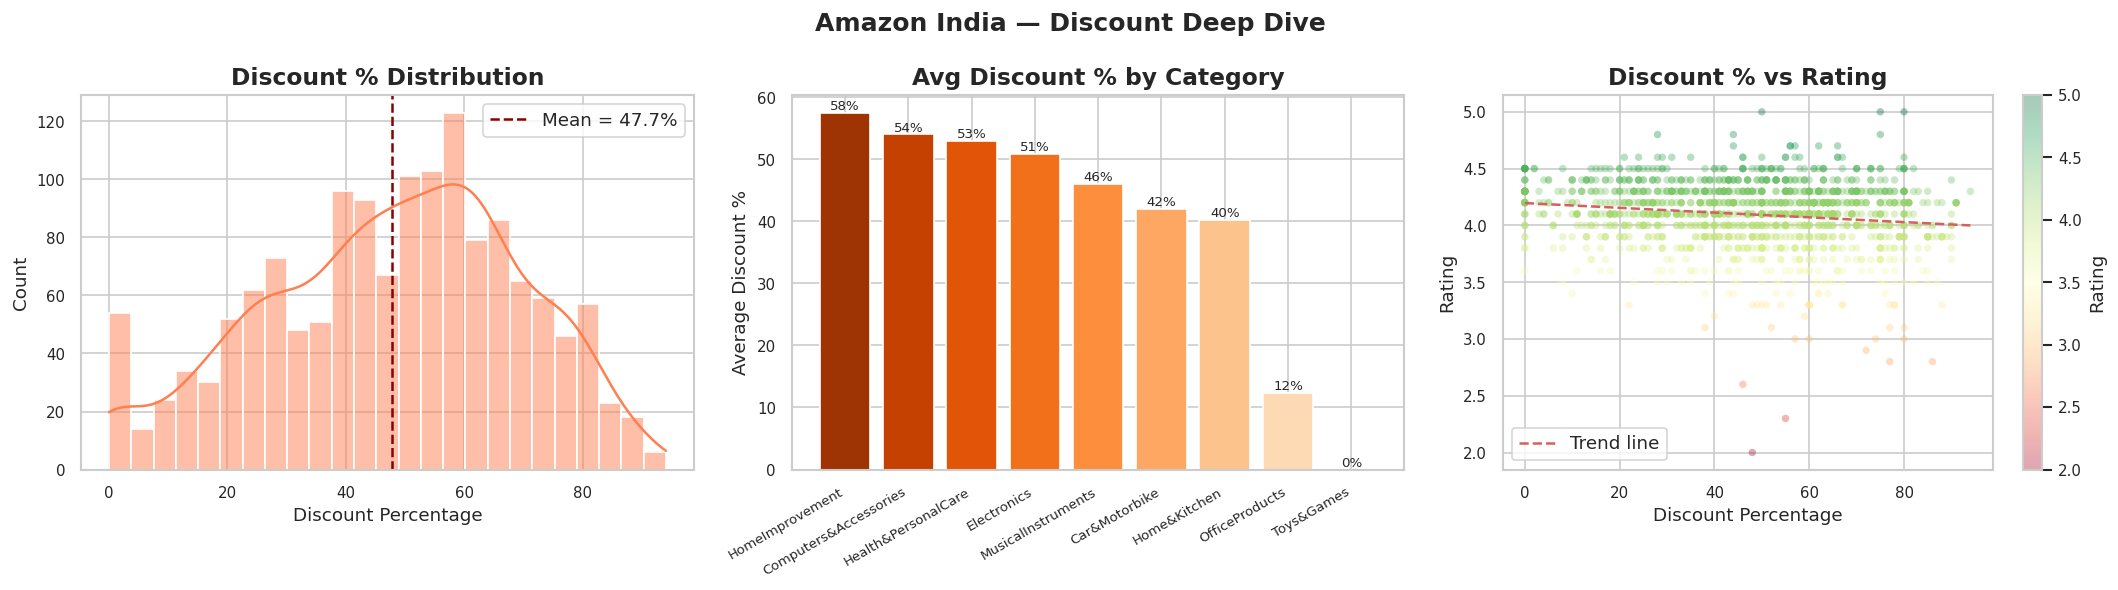

✅ Saved


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_clean['discount_pct'], bins=25, kde=True, color='coral', edgecolor='white', ax=axes[0])
axes[0].axvline(df_clean['discount_pct'].mean(), color='darkred', linestyle='--',
                label=f"Mean = {df_clean['discount_pct'].mean():.1f}%")
axes[0].set_title('Discount % Distribution')
axes[0].set_xlabel('Discount Percentage')
axes[0].legend()

cat_disc = df_clean.groupby('main_category')['discount_pct'].mean().sort_values(ascending=False)
axes[1].bar(range(len(cat_disc)), cat_disc.values,
            color=sns.color_palette('Oranges_r', n_colors=len(cat_disc)))
axes[1].set_xticks(range(len(cat_disc)))
axes[1].set_xticklabels(cat_disc.index, rotation=30, ha='right', fontsize=8)
axes[1].set_title('Avg Discount % by Category')
axes[1].set_ylabel('Average Discount %')
for i, v in enumerate(cat_disc.values):
    axes[1].text(i, v + 0.5, f'{v:.0f}%', ha='center', fontsize=8)

scatter = axes[2].scatter(df_clean['discount_pct'], df_clean['rating'],
                          alpha=0.35, c=df_clean['rating'], cmap='RdYlGn',
                          edgecolors='none', s=20)
z = np.polyfit(df_clean['discount_pct'].dropna(), df_clean['rating'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['discount_pct'].min(), df_clean['discount_pct'].max(), 100)
axes[2].plot(x_line, p(x_line), 'r--', linewidth=1.5, label='Trend line')
axes[2].set_title('Discount % vs Rating')
axes[2].set_xlabel('Discount Percentage')
axes[2].set_ylabel('Rating')
axes[2].legend()
plt.colorbar(scatter, ax=axes[2], label='Rating')

plt.suptitle('Amazon India — Discount Deep Dive', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz3_discount_analysis.png', bbox_inches='tight')
plt.show()
print("✅ Saved")


## Visualization 4 — Price Range Analysis

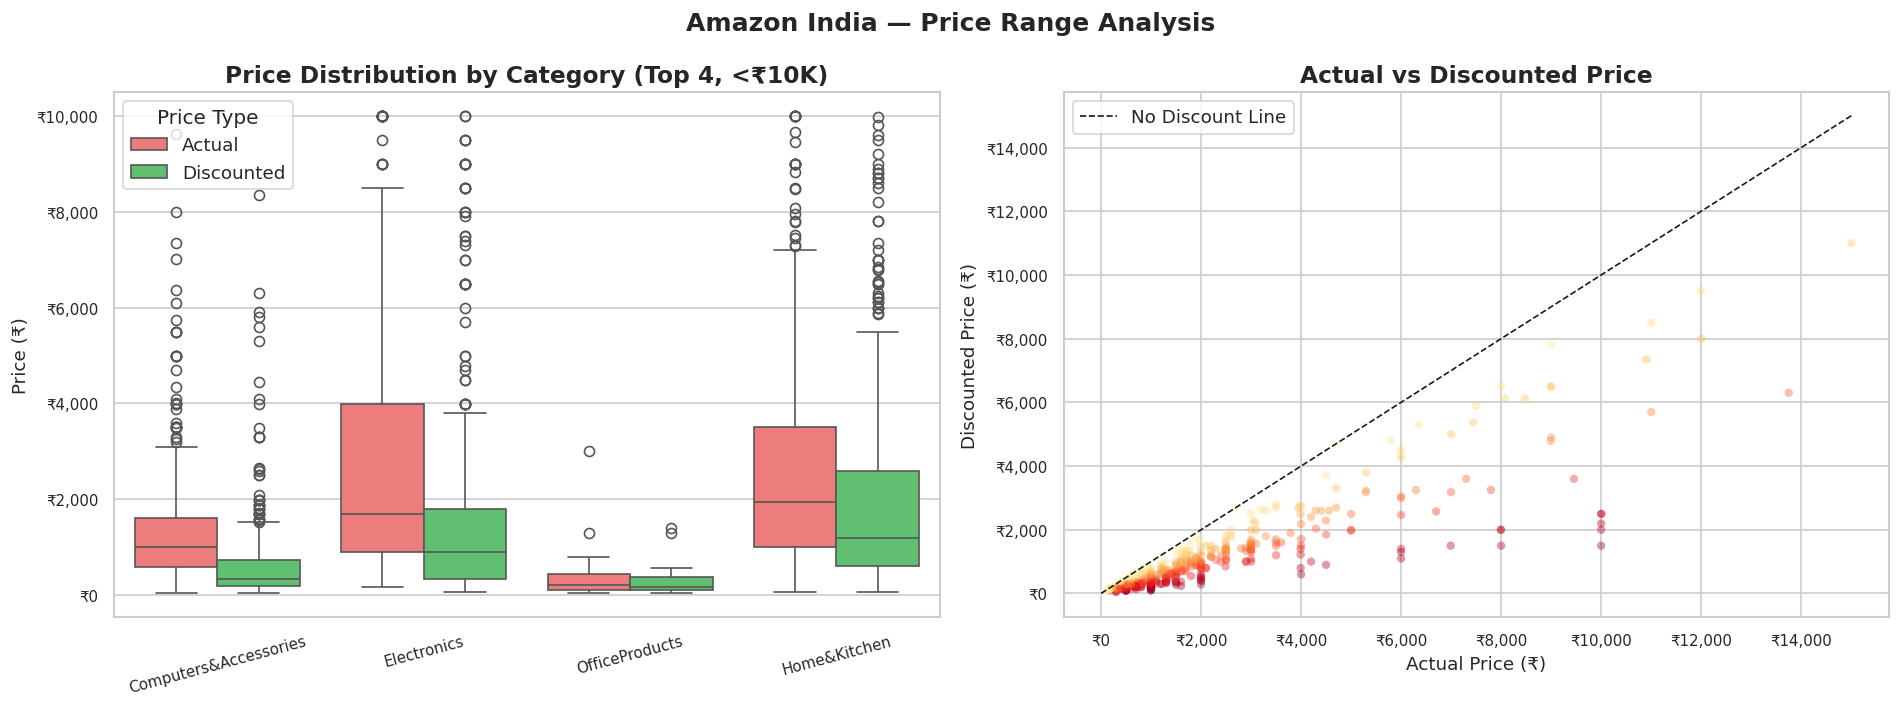

✅ Saved


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_cats = df_clean['main_category'].value_counts().nlargest(4).index
df_top = df_clean[df_clean['main_category'].isin(top_cats)]
df_melt = df_top.melt(id_vars='main_category',
                       value_vars=['actual_price','discounted_price'],
                       var_name='Price Type', value_name='Price (₹)')
df_melt['Price Type'] = df_melt['Price Type'].map({'actual_price':'Actual','discounted_price':'Discounted'})

sns.boxplot(data=df_melt[df_melt['Price (₹)'] < 10000],
            x='main_category', y='Price (₹)', hue='Price Type',
            palette={'Actual':'#ff6b6b','Discounted':'#51cf66'}, ax=axes[0])
axes[0].set_title('Price Distribution by Category (Top 4, <₹10K)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{int(x):,}'))
axes[0].legend(title='Price Type')

sample = df_clean[df_clean['actual_price'] < 15000].sample(min(400, len(df_clean)), random_state=42)
axes[1].scatter(sample['actual_price'], sample['discounted_price'],
                alpha=0.4, c=sample['discount_pct'], cmap='YlOrRd', s=25, edgecolors='none')
max_val = max(sample['actual_price'].max(), sample['discounted_price'].max())
axes[1].plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='No Discount Line')
axes[1].set_title('Actual vs Discounted Price')
axes[1].set_xlabel('Actual Price (₹)')
axes[1].set_ylabel('Discounted Price (₹)')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{int(x):,}'))
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{int(x):,}'))
axes[1].legend()

plt.suptitle('Amazon India — Price Range Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz4_price_analysis.png', bbox_inches='tight')
plt.show()
print("✅ Saved")


## Visualization 5 — Correlation Heatmap

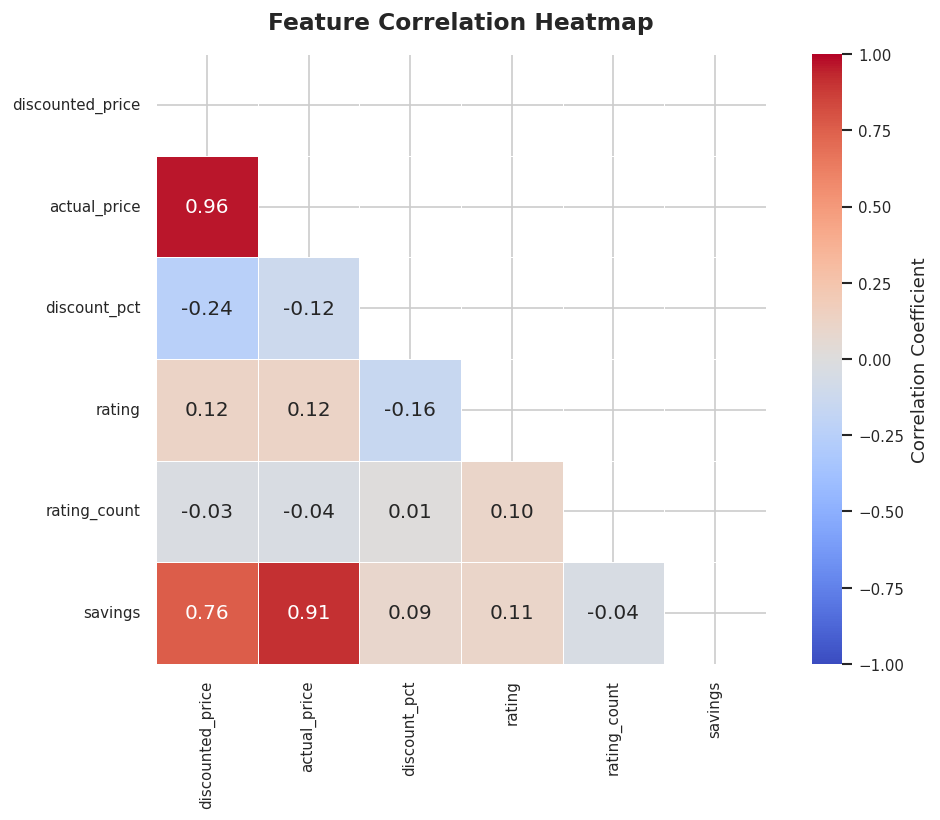

✅ Saved


In [7]:
fig, ax = plt.subplots(figsize=(9, 7))

corr = df_clean[['discounted_price','actual_price','discount_pct',
                  'rating','rating_count','savings']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, square=True,
            cbar_kws={'label':'Correlation Coefficient'}, ax=ax)
ax.set_title('Feature Correlation Heatmap', pad=15)
plt.tight_layout()
plt.savefig('viz5_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("✅ Saved")


## Visualization 6 — Top 15 Most-Reviewed Products

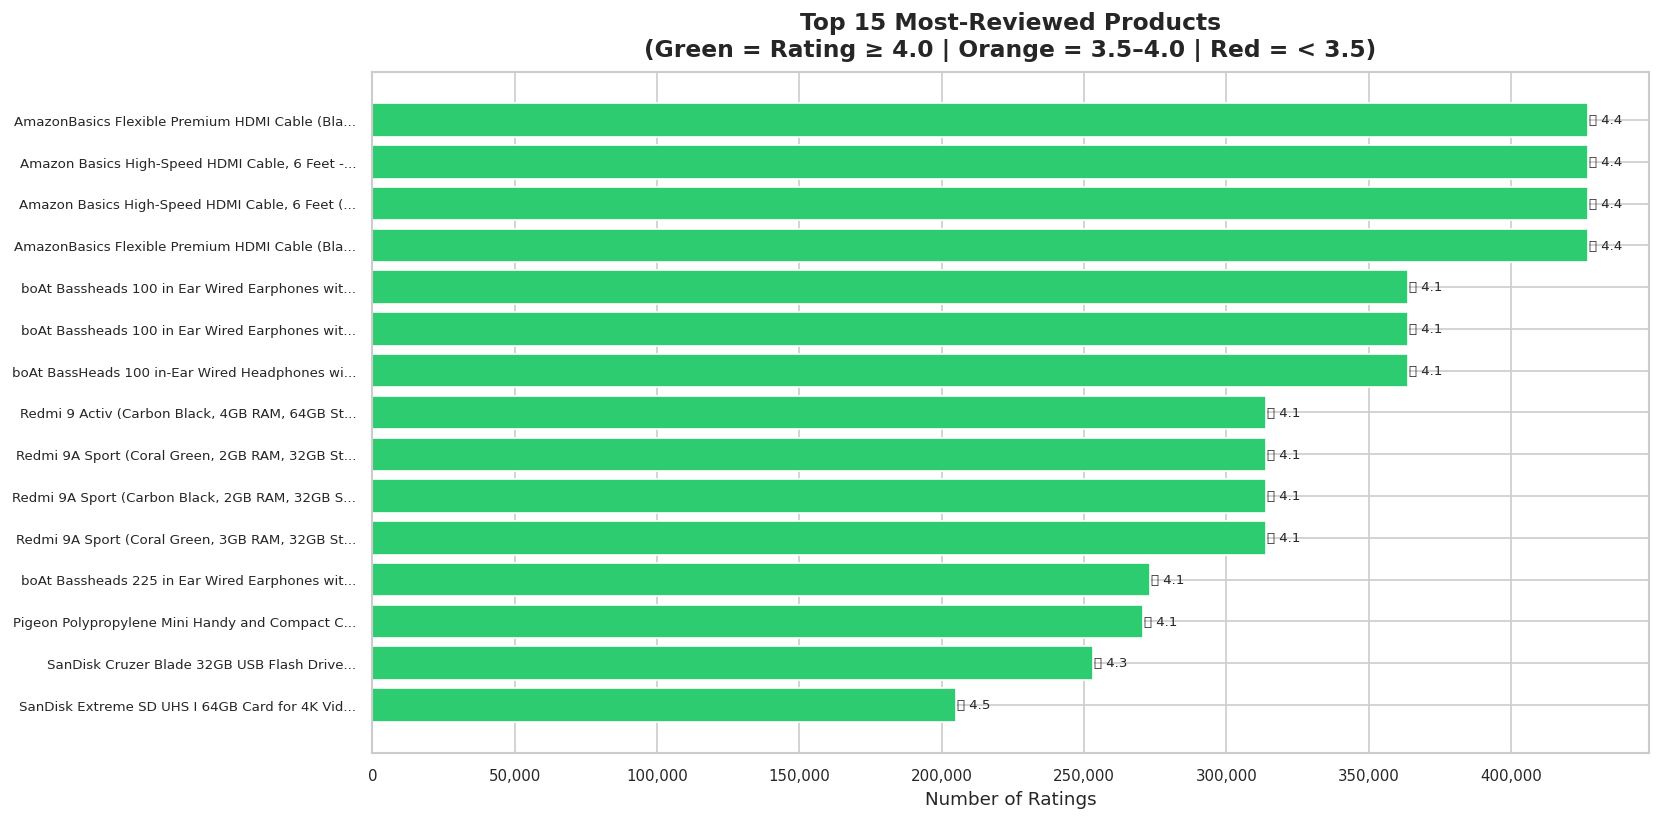

✅ Saved


In [8]:
top_reviewed = df_clean.nlargest(15, 'rating_count')[['product_name','rating','rating_count','main_category']].copy()
top_reviewed['short_name'] = top_reviewed['product_name'].str[:45] + '...'

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#2ecc71' if r >= 4.0 else '#e74c3c' if r < 3.5 else '#f39c12'
          for r in top_reviewed['rating']]

bars = ax.barh(range(len(top_reviewed)), top_reviewed['rating_count'], color=colors, edgecolor='white')
ax.set_yticks(range(len(top_reviewed)))
ax.set_yticklabels(top_reviewed['short_name'], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Number of Ratings')
ax.set_title('Top 15 Most-Reviewed Products\n(Green = Rating ≥ 4.0 | Orange = 3.5–4.0 | Red = < 3.5)', pad=10)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, (bar, row) in enumerate(zip(bars, top_reviewed.itertuples())):
    ax.text(bar.get_width() + 300, i, f'⭐ {row.rating}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('viz6_top_reviewed.png', bbox_inches='tight')
plt.show()
print("✅ Saved")


## Visualization 7 — Avg Rating by Discount Bucket

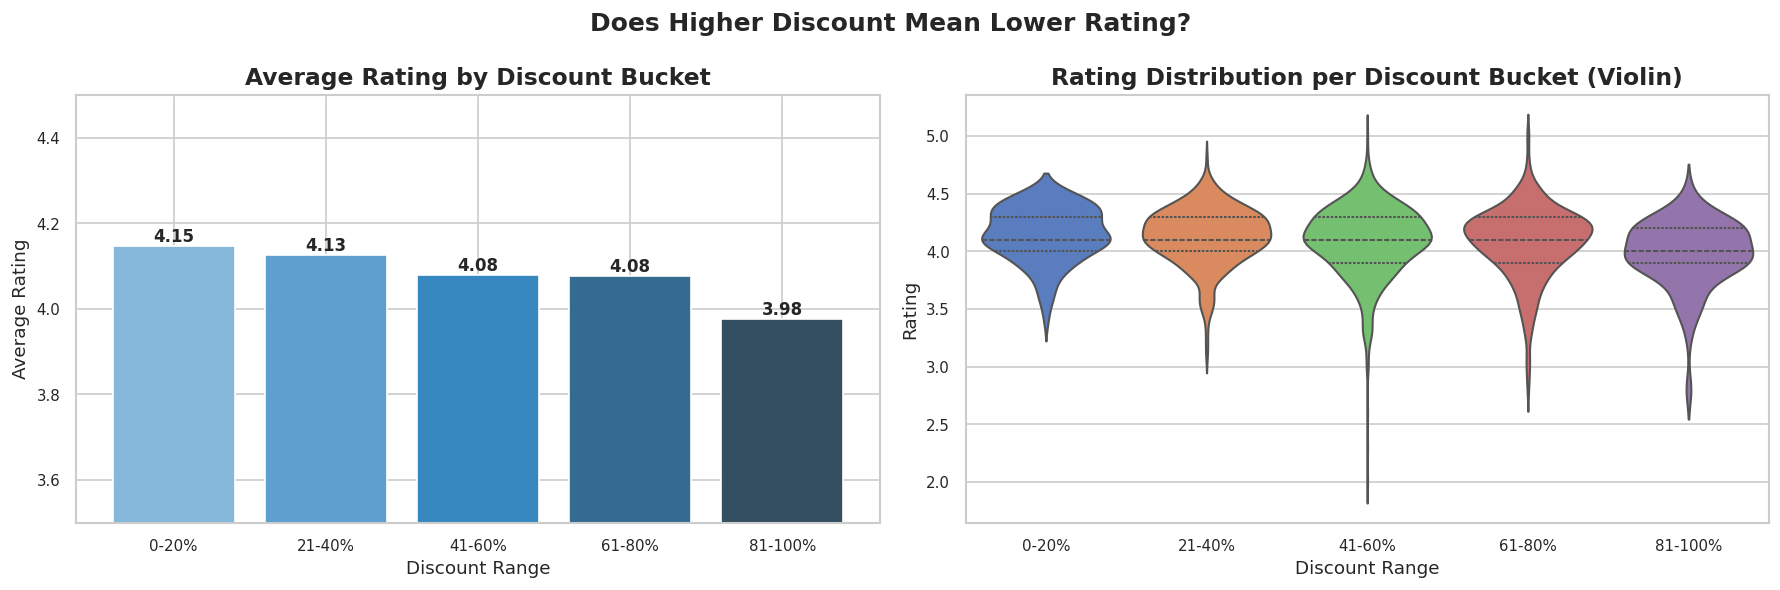

✅ Saved


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bucket_data = df_clean.groupby('discount_bucket', observed=True).agg(
    avg_rating=('rating','mean'), count=('rating','count')).reset_index()

palette = sns.color_palette('Blues_d', n_colors=len(bucket_data))
bars = axes[0].bar(bucket_data['discount_bucket'].astype(str), bucket_data['avg_rating'],
                   color=palette, edgecolor='white')
axes[0].set_ylim(3.5, 4.5)
axes[0].set_title('Average Rating by Discount Bucket')
axes[0].set_xlabel('Discount Range')
axes[0].set_ylabel('Average Rating')
for bar, val in zip(bars, bucket_data['avg_rating']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

sns.violinplot(data=df_clean[df_clean['discount_pct'].notna()],
               x='discount_bucket', y='rating',
               palette='muted', inner='quartile', ax=axes[1])
axes[1].set_title('Rating Distribution per Discount Bucket (Violin)')
axes[1].set_xlabel('Discount Range')
axes[1].set_ylabel('Rating')

plt.suptitle('Does Higher Discount Mean Lower Rating?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz7_discount_vs_rating_bucket.png', bbox_inches='tight')
plt.show()
print("✅ Saved")


---
## 📌 Visualization Summary

| # | Chart | Key Insight |
|---|---|---|
| 1 | Category Distribution | Electronics leads with ~36% share |
| 2 | Rating Distribution | Most products rate between 3.8–4.5 |
| 3 | Discount Analysis | Avg discount ~47%; weak link with rating |
| 4 | Price Analysis | Higher MRP = bigger absolute cut |
| 5 | Correlation Heatmap | Price & savings correlated; rating is independent |
| 6 | Top Reviewed Products | High reviews ≠ always 5-star rating |
| 7 | Discount Buckets | 80-100% discount products rate slightly lower |

---
*CodeAlpha Data Analytics Internship | Task 3*
